In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [43]:
from tensorflow.keras.models import Model

In [48]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
df=pd.read_excel('/content/english_to_urdu_translation_dataset.xlsx')

In [3]:
df.sample(5)

,eng,urdu
313,he that receiveth a prophet in the name of a p...,جو نبی کے نام سے نبی کو قبول کرتا ہے وہ نبی کا...
4964,for i know that in me that is in my flesh ...,کیونکہ میں جانتا ہوں کہ مجھ میں یعنی میرے جسم ...
2624,saying blessed be the king that cometh in the...,بھیڑ میں سے بعض فریسیوں نے اس سے کہا اے استاد ...
6498,abstain from all appearance of evil,ہر قسم کی بدی سے بچے رہو ۔
3284,then answered the jews and said unto him say...,یہودیوں نے جواب میں اس سے کہا کیا ہم خوب نہیں ...


In [4]:
df.shape

(9103, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9103 entries, 0 to 9102
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   eng     9103 non-null   object
 1   urdu    9102 non-null   object
dtypes: object(2)
memory usage: 142.4+ KB


**Remove Null:**

In [6]:
df.isna().sum()

,0
eng,0
urdu,1


In [7]:
df.dropna(inplace=True)

**Remove Duolicates:**

In [8]:
df.duplicated().sum()

np.int64(9)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.describe()

,eng,urdu
count,9093,9093
unique,8847,9072
top,I am sorry. I am not from here.,ہمارے باپ خدا اور خداوند یسوع مسیح کی طرف سے ت...
freq,6,3


In [11]:
df.columns = ["english","urdu"]

In [12]:
df["english"] = df["english"].str.lower()

In [13]:
df["urdu"] = ("<start> "+ df["urdu"]+ " <end>")

In [14]:
english_sentences = df["english"].values
urdu_sentences = df["urdu"].values

**Tokenization:**

In [15]:
english_tokenizer = Tokenizer(filters="")
urdu_tokenizer = Tokenizer(filters="")

In [18]:
english_tokenizer.fit_on_texts(english_sentences)

In [19]:
english_tokenizer.word_index

{'the': 1,
 'and': 2,
 'of': 3,
 'that': 4,
 'to': 5,
 'he': 6,
 'in': 7,
 'him': 8,
 'i': 9,
 'unto': 10,
 'for': 11,
 'is': 12,
 'not': 13,
 'a': 14,
 'they': 15,
 'be': 16,
 'them': 17,
 'but': 18,
 'ye': 19,
 'which': 20,
 'his': 21,
 'you': 22,
 'shall': 23,
 'was': 24,
 'with': 25,
 'god': 26,
 'it': 27,
 'all': 28,
 'have': 29,
 'as': 30,
 'said': 31,
 'are': 32,
 'when': 33,
 'jesus': 34,
 'man': 35,
 'we': 36,
 'me': 37,
 'this': 38,
 'thou': 39,
 'by': 40,
 'were': 41,
 'from': 42,
 'things': 43,
 'lord': 44,
 'my': 45,
 'had': 46,
 'into': 47,
 'one': 48,
 'if': 49,
 'on': 50,
 'come': 51,
 'also': 52,
 'then': 53,
 'there': 54,
 'will': 55,
 'christ': 56,
 'hath': 57,
 'out': 58,
 'came': 59,
 'your': 60,
 'us': 61,
 'their': 62,
 'thee': 63,
 'no': 64,
 'do': 65,
 'saying': 66,
 'what': 67,
 'say': 68,
 'up': 69,
 'son': 70,
 'at': 71,
 'thy': 72,
 'now': 73,
 'men': 74,
 'these': 75,
 'who': 76,
 'so': 77,
 'should': 78,
 'father': 79,
 'our': 80,
 'therefore': 81,
 'went

In [20]:
english_tokenizer.word_counts

OrderedDict([('the', 22460),
             ('book', 96),
             ('of', 12334),
             ('generation', 74),
             ('jesus', 1966),
             ('christ', 1140),
             ('son', 846),
             ('david', 118),
             ('abraham', 148),
             ('begat', 90),
             ('isaac', 40),
             ('and', 21484),
             ('jacob', 54),
             ('judas', 66),
             ('his', 2978),
             ('brethren', 462),
             ('phares', 6),
             ('zara', 2),
             ('thamar', 2),
             ('esrom', 6),
             ('aram', 6),
             ('aminadab', 6),
             ('naasson', 6),
             ('salmon', 6),
             ('booz', 6),
             ('rachab', 2),
             ('obed', 6),
             ('ruth', 2),
             ('jesse', 10),
             ('king', 180),
             ('solomon', 24),
             ('her', 652),
             ('that', 7636),
             ('had', 1324),
             ('been', 250),
        

In [21]:
urdu_tokenizer.fit_on_texts(urdu_sentences)

In [22]:
urdu_tokenizer.word_index

{'۔': 1,
 '<start>': 2,
 '<end>': 3,
 'اور': 4,
 'کے': 5,
 'سے': 6,
 'میں': 7,
 'اس': 8,
 'کی': 9,
 'ہے': 10,
 'نے': 11,
 'کو': 12,
 'کہ': 13,
 'وہ': 14,
 'تو': 15,
 'کا': 16,
 'جو': 17,
 'ان': 18,
 'نہ': 19,
 'پر': 20,
 'کر': 21,
 'تم': 22,
 'نہیں': 23,
 'ہیں': 24,
 'یہ': 25,
 'کیا': 26,
 'خدا': 27,
 'ہو': 28,
 'کہا': 29,
 'بھی': 30,
 'لئے': 31,
 'اپنے': 32,
 'کیونکہ': 33,
 'ہوں': 34,
 'ایک': 35,
 'تھا': 36,
 'یسوع': 37,
 'ہم': 38,
 'جب': 39,
 'گا': 40,
 'سب': 41,
 'اسے': 42,
 'جس': 43,
 'پاس': 44,
 'خداوند': 45,
 'ساتھ': 46,
 'مگر': 47,
 'پس': 48,
 'ہی': 49,
 'پھر': 50,
 'تھے': 51,
 'بلکہ': 52,
 'طرح': 53,
 'اے': 54,
 'کوئی': 55,
 'کرتا': 56,
 'گیا': 57,
 'مسیح': 58,
 'مجھے': 59,
 'اگر': 60,
 'میرے': 61,
 'دیا': 62,
 'گے': 63,
 'اپنی': 64,
 'تاکہ': 65,
 'کچھ': 66,
 'تک': 67,
 'اسی': 68,
 'لیکن': 69,
 'باپ': 70,
 'کرنے': 71,
 'لے': 72,
 'ایمان': 73,
 'کرتے': 74,
 'جائے': 75,
 'طرف': 76,
 'انہوں': 77,
 'تمہارے': 78,
 'ہوئے': 79,
 'دن': 80,
 'دے': 81,
 'کرے': 82,
 'ہؤا': 83,
 'رہے': 84

In [23]:
urdu_tokenizer.word_counts

OrderedDict([('<start>', 9093),
             ('یسوع', 925),
             ('مسیح', 532),
             ('ابن', 98),
             ('داود', 31),
             ('ابرہام', 69),
             ('کا', 2233),
             ('نسب', 4),
             ('نامہ', 6),
             ('<end>', 9093),
             ('ابراہام', 6),
             ('سے', 6016),
             ('اضحاق', 19),
             ('پیدا', 183),
             ('ہوا', 207),
             ('اور', 8692),
             ('یعقوب', 67),
             ('یہوداہ', 42),
             ('اس', 5690),
             ('کے', 6320),
             ('بھائی', 171),
             ('ہوئے', 358),
             ('۔', 9625),
             ('فارص', 3),
             ('زارح', 1),
             ('تمر', 1),
             ('حصرون', 3),
             ('رام', 2),
             ('عمینداب', 2),
             ('نحسون', 3),
             ('سلمون', 3),
             ('بوعز', 3),
             ('راحب', 3),
             ('عوبید', 3),
             ('روت', 1),
             ('یسّی', 5),
             ('بادش

In [17]:
Tokenizer.oov_token = "<oov>"

.

.

**Text to Sequence:**

In [24]:
encoder_sequences = (english_tokenizer.texts_to_sequences(english_sentences ))

In [25]:
decoder_sequences = (urdu_tokenizer.texts_to_sequences(urdu_sentences ))

In [26]:
max_encoder_len = max(len(seq) for seq in encoder_sequences)
max_decoder_len = max(len(seq) for seq in decoder_sequences)

print(max_encoder_len)
print(max_decoder_len)

68
86


**Padding:**

In [27]:
encoder_input = pad_sequences(
    encoder_sequences,
    maxlen=max_encoder_len,
    padding="post"
)

In [28]:
decoder_input_full = pad_sequences(
    decoder_sequences,
    maxlen=max_decoder_len,
    padding="post"
)

In [29]:
decoder_input = decoder_input_full[:, :-1]

In [30]:
decoder_target = decoder_input_full[:, 1:]

In [31]:
encoder_vocab_size = len(english_tokenizer.word_index) + 1
decoder_vocab_size = len(urdu_tokenizer.word_index) + 1

print(encoder_vocab_size)
print(decoder_vocab_size)

7035
8114


.

**Train Validation Split:**

In [84]:
encoder_train, encoder_val, decoder_train, decoder_val, target_train, target_val = train_test_split(
    encoder_input, decoder_input, decoder_target, test_size=0.2, random_state=42, shuffle=True)

english_train_sentences, english_validation_sentences, urdu_train_sentences, urdu_validation_sentences = train_test_split(
    english_sentences, urdu_sentences, test_size=0.2, random_state=42, shuffle=True)

.

**Build Encoder:**

In [33]:
encoder_inputs = Input(
    shape=(max_encoder_len,),
    name="encoder_inputs"
)

In [34]:
encoder_embedding = Embedding(
    input_dim=encoder_vocab_size,
    output_dim=256,
    mask_zero=True,
    name="encoder_embedding"
)(encoder_inputs)

In [35]:
encoder_lstm = LSTM(256,return_state=True,name='encoder_lstm')

In [36]:
encoder_outputs,state_h,state_c = encoder_lstm(encoder_embedding)

.

.

**Decoder:**

In [37]:
decoder_inputs = Input(
    shape=(max_decoder_len - 1,),
    name="decoder_inputs"
)

In [38]:
decoder_embedding = Embedding(
    input_dim=decoder_vocab_size,
    output_dim=256,
    mask_zero=True,
    name='decoder_embedding'
)(decoder_inputs)

In [39]:
decoder_lstm = LSTM(
    256,
    return_state=True,
    return_sequences=True,
    name='decoder_lstm'
)

In [40]:
decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=[state_h, state_c]
)

In [41]:
decoder_dense = Dense(
    decoder_vocab_size,
    activation="softmax",
    name="output_layer"
)
decoder_outputs = decoder_dense(decoder_outputs)

.

.

In [44]:
training_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

In [45]:
training_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [46]:
decoder_target = np.expand_dims(
    decoder_target,
    axis=-1
)

target_train = np.expand_dims(
    target_train,
    axis=-1
)

target_val = np.expand_dims(
    target_val,
    axis=-1
)

In [47]:
training_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 68)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 85)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 68, 256)   │  1,800,960 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 68)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 85, 256)   │  2,077,184 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    525,312 │ encoder_embeddin… │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 85, 256), │    525,312 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 85, 8114)  │  2,085,298 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,014,066 (26.76 MB)

 Trainable params: 7,014,066 (26.76 MB)

 Non-trainable params: 0 (0.00 B)

**Early Stop:**

In [49]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True
)

**Model CheckPoint:**

In [50]:
checkpoint = ModelCheckpoint(
    "language_translation_model.keras",
    verbose=1,
    save_best_only=True,
    monitor="val_loss"
)

In [51]:
history = training_model.fit([encoder_train,decoder_train],target_train,validation_data=([encoder_val,decoder_val],target_val),
                             epochs=50,batch_size=64,callbacks=[early_stop,checkpoint])

Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.0628 - loss: 7.0942
Epoch 1: val_loss improved from None to 5.73033, saving model to language_translation_model.keras

Epoch 1: finished saving model to language_translation_model.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.0841 - loss: 6.3334 - val_accuracy: 0.1376 - val_loss: 5.7303
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1444 - loss: 5.5620
Epoch 2: val_loss improved from 5.73033 to 5.30599, saving model to language_translation_model.keras

Epoch 2: finished saving model to language_translation_model.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.1509 - loss: 5.4617 - val_accuracy: 0.1662 - val_loss: 5.3060
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.1726 - loss: 5.1767
Epoch 3: val_loss improved from 5.30599 to 5.05578, saving model to language_translation_model.keras

Epoch 3: finished saving model to language_translation_model.k

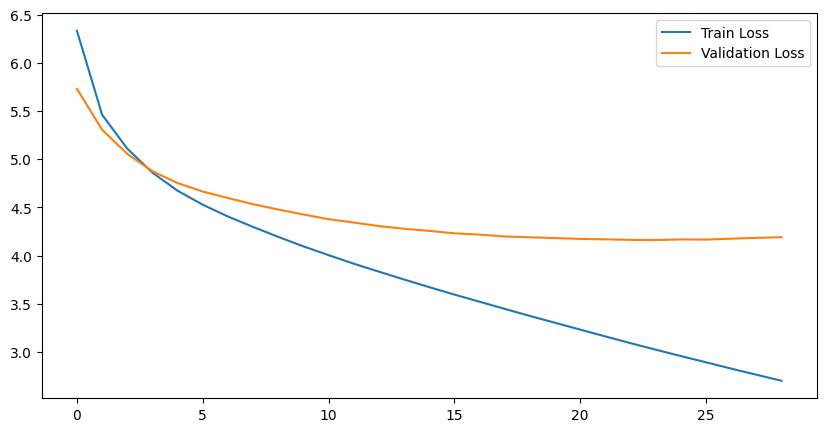

In [52]:
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.legend()
plt.show()

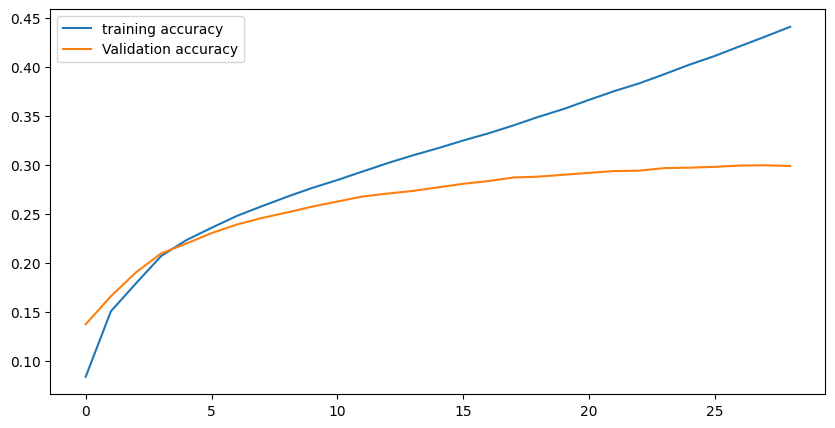

In [53]:
plt.figure(figsize=(10,5))
plt.plot(history.history["accuracy"],label="training accuracy")
plt.plot(history.history["val_accuracy"],label="Validation accuracy")
plt.legend()
plt.show()

**Save Tokenizers:**

In [54]:
import pickle

In [55]:
with open("english_tokenizer.pkl","wb") as f:
    pickle.dump(english_tokenizer,f)

In [56]:
with open("urdu_tokenizer.pkl","wb") as f:
    pickle.dump(urdu_tokenizer,f)

.

.

**Encoder Inference Model:**

In [57]:
encoder_model = Model(
    encoder_inputs,
    [state_h, state_c]
)

**Decoder Inference Model:**

In [60]:
decoder_state_input_h = Input(
    shape=(256,),
    name="decoder_state_input_h"
)

In [61]:
decoder_state_input_c = Input(
    shape=(256,),
    name="decoder_state_input_c"
)

In [63]:
decoder_inputs_single = Input(shape=(1,), name="decoder_word_input")
decoder_embedding_layer_obj = training_model.get_layer('decoder_embedding')
decoder_embedding_inf = decoder_embedding_layer_obj(decoder_inputs_single)

In [64]:
decoder_outputs, state_h_new, state_c_new = decoder_lstm(
    decoder_embedding_inf,
    initial_state=[
        decoder_state_input_h,
        decoder_state_input_c
    ]
)

In [65]:
decoder_outputs = decoder_dense(decoder_outputs)

**Decoder Model:**

In [66]:
decoder_model = Model(

    [
        decoder_inputs_single,
        decoder_state_input_h,
        decoder_state_input_c
    ],

    [
        decoder_outputs,
        state_h_new,
        state_c_new
    ]
)

In [67]:
reverse_urdu_index = {
    index: word
    for word, index in urdu_tokenizer.word_index.items()
}

**Translation Function:**

**Translation Loop:**

In [74]:
def translate(sentence):

    sequence = english_tokenizer.texts_to_sequences([sentence])
    sequence = pad_sequences(
        sequence,
        maxlen=max_encoder_len,
        padding="post"
    )

    states = encoder_model.predict(sequence, verbose=0)
    target_seq = np.array(
        [[urdu_tokenizer.word_index["<start>"]]]
    )

    translated_sentence = []

    while True:

        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states,
            verbose=0
        )

        predicted_id = np.argmax(output_tokens[0, -1, :])

        predicted_word = reverse_urdu_index.get(predicted_id)

        if predicted_word == "<end>":
            break

        translated_sentence.append(predicted_word)

        target_seq = np.array([[predicted_id]])

        states = [h, c]

    return " ".join(translated_sentence)

In [76]:
translate("how are you")

'آپ کیا کروں؟'

In [77]:
translate("what is your name")

'تم کیا کیا ہے کہ وہ غلط ہے۔'

In [78]:
translate("how are you doing")

'آپ کیا کروں؟'

**BLEU:**

In [79]:
!pip install nltk

In [80]:
import nltk
from nltk.translate.bleu_score import sentence_bleu

In [88]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

references = []
candidates = []

for english, actual in zip(
    english_validation_sentences,
    urdu_validation_sentences
):
    prediction = translate(english)

    references.append([actual.split()])
    candidates.append(prediction.split())

smooth = SmoothingFunction().method1

bleu = corpus_bleu(
    references,
    candidates,
    smoothing_function=smooth
)

print(f"Corpus BLEU: {bleu:.4f}")

Corpus BLEU: 0.0280


In [90]:
results = []

for english, actual in zip(
    english_validation_sentences[:20],
    urdu_validation_sentences[:20]
):

    prediction = translate(english)

    results.append([
        english,
        actual,
        prediction
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "English",
        "Actual Urdu",
        "Predicted Urdu"
    ]
)

results_df

,English,Actual Urdu,Predicted Urdu
0,for ye may all prophesy one by one that all m...,<start> کیونکہ تم سب کے سب ایک ایک کرکے نبوّت ...,کیونکہ تم سب باتوں کے لئے دعا کرو گے اور سب چی...
1,his car is two years old.,<start> ان کی گاڑی دو سال پرانی ہے۔ <end>,اس کی بہن کے لئیے کافی ہے۔
2,woe unto you for ye build the sepulchres of t...,<start> تم پر افسوس کہ تم تو نبیوں کی قبروں کو...,اے ریاکار فقیہو اور فریسیو تم سے سچ کہتا ہوں ک...
3,and the disciples did as jesus had appointed t...,<start> اور جیسا یسوع نے شاگردوں کو حکم دیا تھ...,اور اس نے ان سے کہا کہ یہ سب کچھ میں بھی اس کے...
4,and he entered into one of the ships which wa...,<start> اور اس نے ان کشتیوں میں سے ایک پر چڑھ ...,جب وہ اس کے پاس آئے تو اس کے پاس آئے تو اس کے ...
5,and some began to spit on him and to cover hi...,<start> تب بعض اس پر تھوکنے اور اس کا منہ ڈھان...,جب اس نے اس کے پاس آکر اس کے پاس آکر اس کے پاس...
6,and when he had thus spoken he dismissed the ...,<start> یہ کہہ کر اس نے مجلس کر برخاست کیا ۔ <...,اور وہ اسے بھوک لگی ۔
7,but they shook off the dust of their feet agai...,<start> یہ اپنے پاؤں کی خاک ان کے سامنے جھاڑ ...,پس انہوں نے اس کے پاس آکر اس کے ساتھ اور ان کے...
8,i have a debt to pay.,<start> مجھے ایک قرض چکانا ہے۔ <end>,مجھے کھیل پسند ہے ۔
9,but this man because he continueth ever hath...,<start> مگر چونکہ یہ ابد تک قائم رہنے والا ہے ...,لیکن اس کے پاس اس کے پاس نہیں بلکہ اس کے لئے ن...
